(np.float64(-0.5), np.float64(2015.5), np.float64(1511.5), np.float64(-0.5))

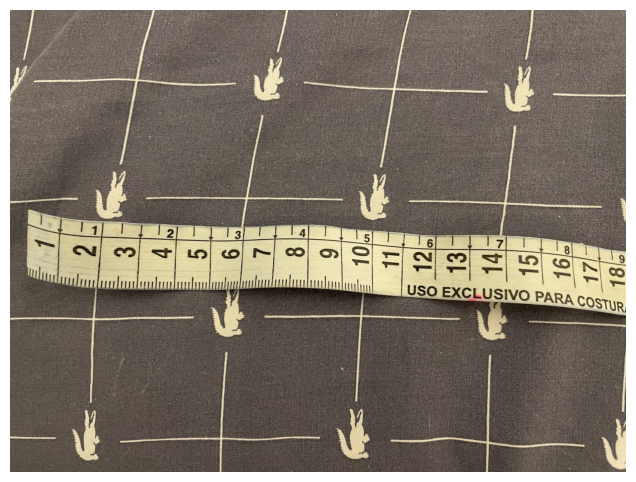

In [1]:
import cv2
import matplotlib.pyplot as plt

image_path = "./data/processed/fita_metrica/IMG_0099.jpg"

image = cv2.imread(image_path)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))
plt.imshow(image_rgb)
plt.axis("off")

Número de keypoints: 10155
Formato dos descritores: (10155, 128)


(np.float64(-0.5), np.float64(2015.5), np.float64(1511.5), np.float64(-0.5))

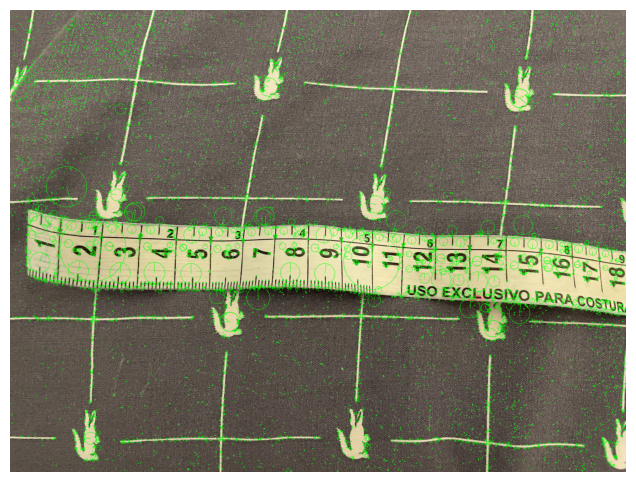

In [2]:
from src.features import detect_sift

keypoints, descriptors = detect_sift(image)

print("Número de keypoints:", len(keypoints))
print("Formato dos descritores:", descriptors.shape)

image_keypoints = cv2.drawKeypoints(
    image,
    keypoints,
    None,
    color=(0, 255, 0),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

image_keypoints = cv2.cvtColor(
    image_keypoints,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 6))
plt.imshow(image_keypoints)
plt.axis("off")

Número de keypoints: 500
Formato dos descritores: (500, 32)


(np.float64(-0.5), np.float64(2015.5), np.float64(1511.5), np.float64(-0.5))

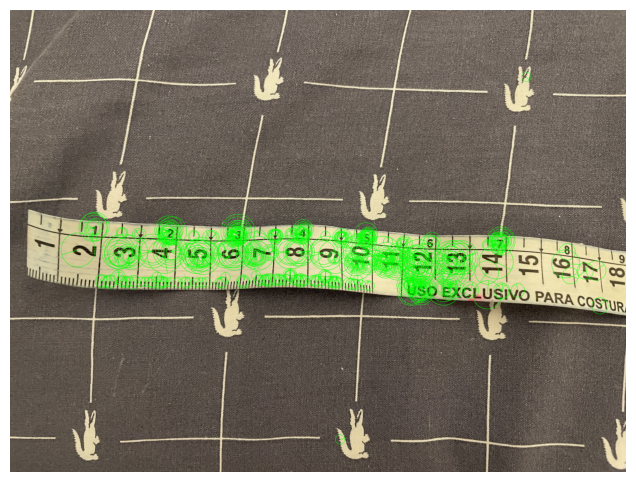

In [3]:
from src.features import detect_orb

keypoints_orb, descriptors_orb = detect_orb(image)

print("Número de keypoints:", len(keypoints_orb))
print("Formato dos descritores:", descriptors_orb.shape)

image_keypoints_orb = cv2.drawKeypoints(
    image,
    keypoints_orb,
    None,
    color=(0, 255, 0),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

image_keypoints_orb = cv2.cvtColor(
    image_keypoints_orb,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 6))
plt.imshow(image_keypoints_orb)
plt.axis("off")

Imagem 1: 10155 keypoints
Imagem 2: 13303 keypoints
Pares de matches: 10155
Matches após Lowe Ratio Test: 693


(np.float64(-0.5), np.float64(4031.5), np.float64(1511.5), np.float64(-0.5))

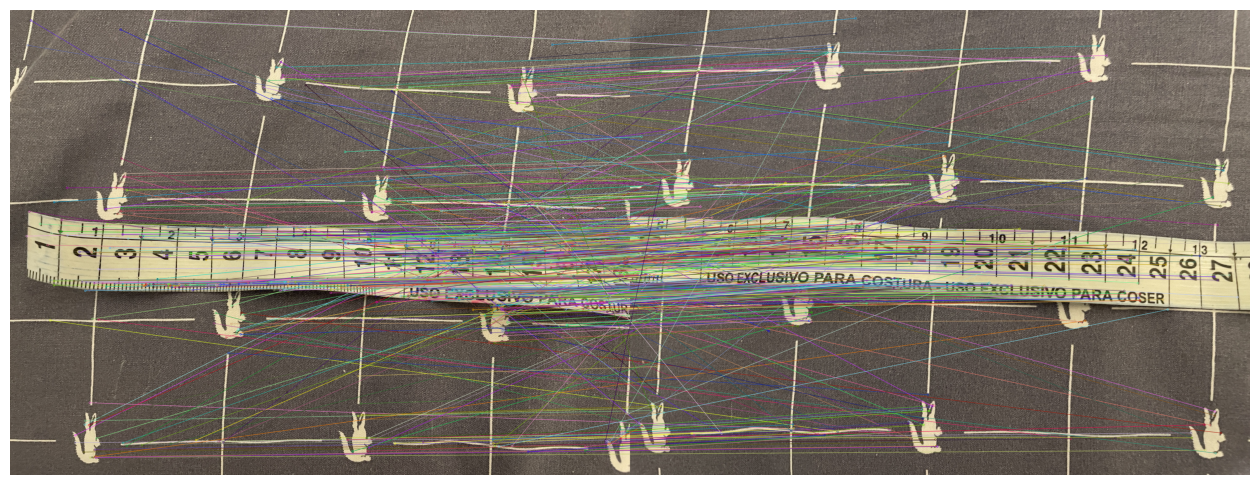

In [4]:
from src.matching import match_descriptors, ratio_test

image1 = cv2.imread("./data/processed/fita_metrica/IMG_0099.jpg")
image2 = cv2.imread("./data/processed/fita_metrica/IMG_0100.jpg")

keypoints1, descriptors1 = detect_sift(image1)
keypoints2, descriptors2 = detect_sift(image2)

print("Imagem 1:", len(keypoints1), "keypoints")
print("Imagem 2:", len(keypoints2), "keypoints")

matches = match_descriptors(
    descriptors1,
    descriptors2,
    method="sift"
)

print("Pares de matches:", len(matches))
good_matches = ratio_test(matches, ratio=0.75)

print("Matches após Lowe Ratio Test:", len(good_matches))

matched_image = cv2.drawMatches(
    image1,
    keypoints1,
    image2,
    keypoints2,
    good_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

matched_image = cv2.cvtColor(
    matched_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(16, 8))
plt.imshow(matched_image)
plt.axis("off")

In [5]:
from pathlib import Path
import cv2
import random

image_dir = Path("./data/processed/fita_metrica/")

images = []

for image_path in sorted(image_dir.iterdir()):
    if image_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
        continue

    image = cv2.imread(str(image_path))

    if image is None:
        print(f"Não foi possível carregar: {image_path}")
        continue

    images.append(image)

# random.shuffle(images)

In [6]:
from src.matching import match_descriptors, ratio_test

# Detectar uma única vez
keypoints = []
descriptors = []

for image in images:
    kp, desc = detect_orb(image)

    keypoints.append(kp)
    descriptors.append(desc)

match_counts = {}

for i in range(len(images)):
    for j in range(i + 1, len(images)):

        matches = match_descriptors(
            descriptors[i],
            descriptors[j],
            method="orb"
        )

        good_matches = ratio_test(
            matches,
            ratio=0.75
        )

        match_counts[(i, j)] = len(good_matches)

        print(
            f"{i} <-> {j}: "
            f"{len(good_matches)} matches"
        )

0 <-> 1: 68 matches
0 <-> 2: 10 matches
0 <-> 3: 19 matches
0 <-> 4: 19 matches
0 <-> 5: 15 matches
0 <-> 6: 35 matches
0 <-> 7: 10 matches
1 <-> 2: 18 matches
1 <-> 3: 16 matches
1 <-> 4: 13 matches
1 <-> 5: 18 matches
1 <-> 6: 19 matches
1 <-> 7: 10 matches
2 <-> 3: 75 matches
2 <-> 4: 29 matches
2 <-> 5: 36 matches
2 <-> 6: 36 matches
2 <-> 7: 20 matches
3 <-> 4: 64 matches
3 <-> 5: 47 matches
3 <-> 6: 41 matches
3 <-> 7: 31 matches
4 <-> 5: 68 matches
4 <-> 6: 40 matches
4 <-> 7: 25 matches
5 <-> 6: 90 matches
5 <-> 7: 42 matches
6 <-> 7: 53 matches


In [7]:
from src.ordering import build_connectivity_matrix

connectivity_matrix = build_connectivity_matrix(
    match_counts
)

print(connectivity_matrix)

[[ 0 68 10 19 19 15 35 10]
 [68  0 18 16 13 18 19 10]
 [10 18  0 75 29 36 36 20]
 [19 16 75  0 64 47 41 31]
 [19 13 29 64  0 68 40 25]
 [15 18 36 47 68  0 90 42]
 [35 19 36 41 40 90  0 53]
 [10 10 20 31 25 42 53  0]]


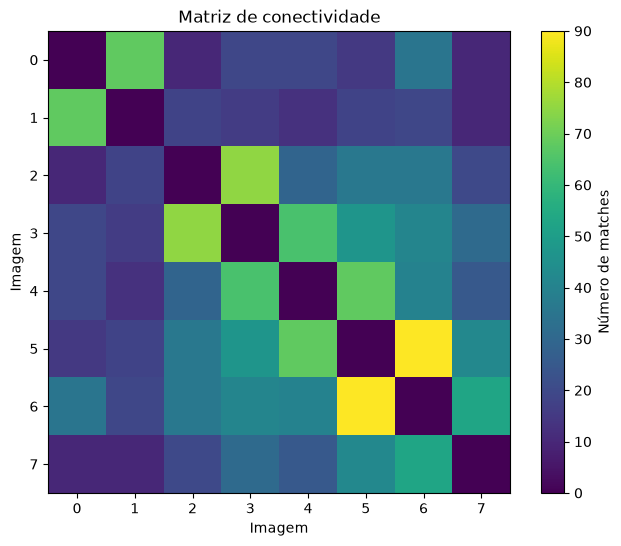

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(
    connectivity_matrix,
    cmap="viridis"
)

plt.colorbar(label="Número de matches")

plt.xlabel("Imagem")
plt.ylabel("Imagem")
plt.title("Matriz de conectividade")

plt.show()

In [9]:
from src.ordering import build_graph

graph = build_graph(
    connectivity_matrix,
    min_matches=50
)

print(graph)

{0: [1], 1: [0], 2: [3], 3: [2, 4], 4: [3, 5], 5: [4, 6], 6: [5, 7], 7: [6]}


In [10]:
from src.homography import (
    estimate_homography,
    inlier_rate,
    reprojection_error
)

i = 0
j = 1

matches = match_descriptors(
    descriptors[i],
    descriptors[j],
    method="orb"
)

good_matches = ratio_test(matches, ratio=0.75)

H, mask = estimate_homography(
    keypoints[i],
    keypoints[j],
    good_matches
)

rate = inlier_rate(mask)

error = reprojection_error(
    keypoints[i],
    keypoints[j],
    good_matches,
    H,
    mask
)

print("Good matches:", len(good_matches))
print("Inliers:", int(mask.sum()) if mask is not None else 0)
print("Taxa de inliers:", rate)
print("Erro médio de reprojeção:", error)

Good matches: 68
Inliers: 24
Taxa de inliers: 0.35294117647058826
Erro médio de reprojeção: 1.1496084928512573


In [11]:
import numpy as np

height1, width1 = images[i].shape[:2]
height2, width2 = images[j].shape[:2]

corners1 = np.float32([
    [0, 0],
    [width1, 0],
    [width1, height1],
    [0, height1]
]).reshape(-1, 1, 2)

corners2 = np.float32([
    [0, 0],
    [width2, 0],
    [width2, height2],
    [0, height2]
]).reshape(-1, 1, 2)

transformed_corners1 = cv2.perspectiveTransform(
    corners1,
    H
)

all_corners = np.concatenate([
    transformed_corners1,
    corners2
])

[x_min, y_min] = np.floor(
    all_corners.min(axis=0).ravel()
).astype(int)

[x_max, y_max] = np.ceil(
    all_corners.max(axis=0).ravel()
).astype(int)

translation = np.array([
    [1, 0, -x_min],
    [0, 1, -y_min],
    [0, 0, 1]
], dtype=np.float64)

canvas_width = x_max - x_min
canvas_height = y_max - y_min

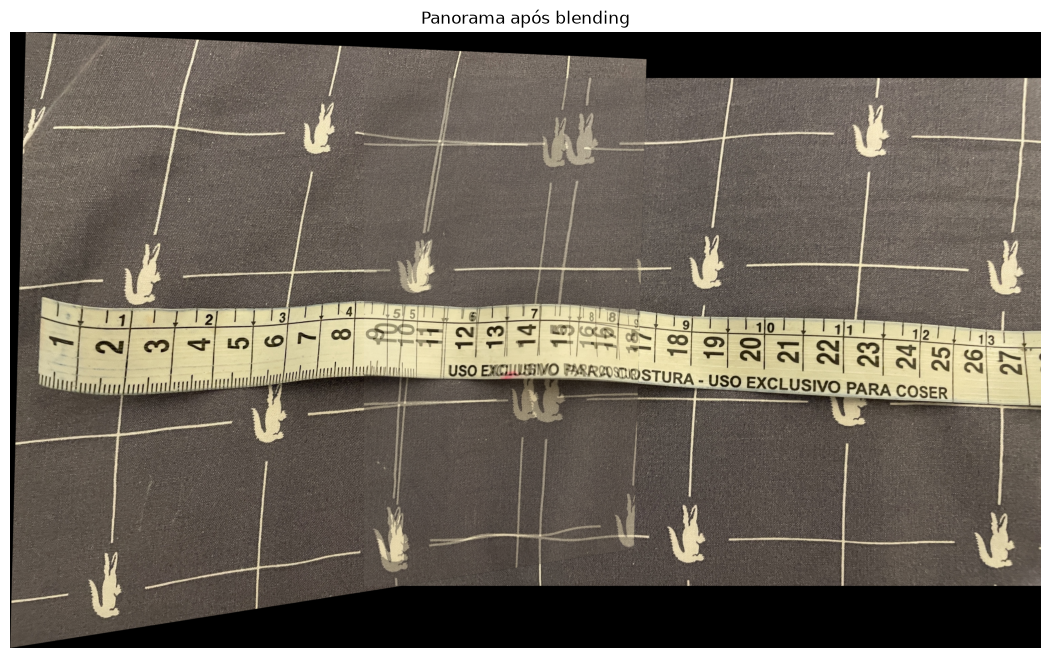

In [12]:
from src.blending import blend_images

warped1 = cv2.warpPerspective(
    images[i],
    translation @ H,
    (canvas_width, canvas_height)
)

warped2 = cv2.warpPerspective(
    images[j],
    translation,
    (canvas_width, canvas_height)
)

panorama = blend_images(warped1, warped2)

plt.figure(figsize=(16, 8))

plt.imshow(cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB))

plt.axis("off")
plt.title("Panorama após blending")
plt.show()